In [ ]:
import pandas as pd
from nilearn.glm.first_level import FirstLevelModel
from nilearn.plotting import plot_glass_brain
from nilearn.plotting import plot_design_matrix
from pathlib import Path

### **Notebook: Example of a quick GLM analysis for one subject**

#### **Localizer**

In [ ]:
BASE_PATH = Path("/specify/your/base/path")
fmri_loca = BASE_PATH / f"sub-01_task-localizer_dir-ap_space-MNI152NLin6Asym_res-02_desc-preproc_bold.nii.gz"
localizer_events = BASE_PATH / f"sub-1_localizer_events.tsv"
fmriprep_filename = BASE_PATH / f"sub-01_task-localizer_dir-ap_desc-confounds_timeseries.tsv"

In [3]:
df_localizer_events = pd.read_csv(localizer_events, sep='\t')

In [4]:
df_localizer_events = df_localizer_events.rename(columns={'ttrial_type': 'trial_type'})
df_confounds = pd.read_csv(fmriprep_filename, sep='\t')
selected_confounds = df_confounds[["csf", "white_matter", 
                                    "trans_x", "trans_y", "trans_z", 
                                    "rot_x", "rot_y", "rot_z"]]

<Axes: label='conditions', ylabel='scan number'>

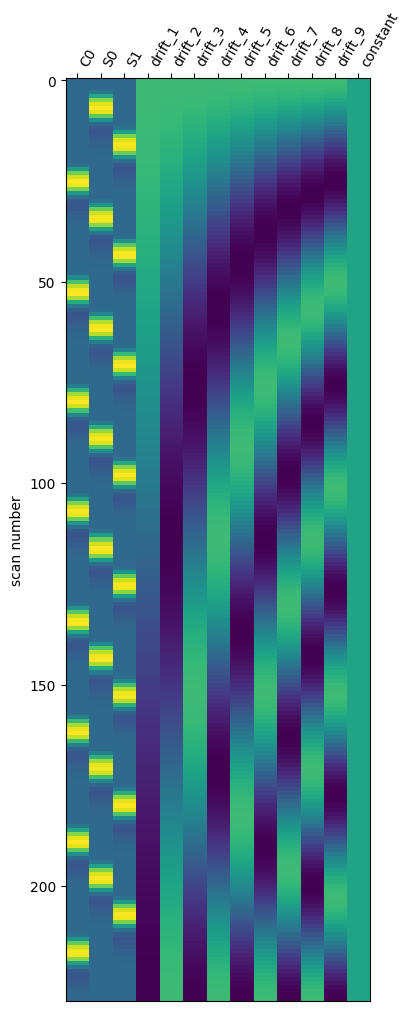

In [5]:
mod = FirstLevelModel(
    t_r=2.0,
    noise_model="ar1",
    standardize=False,
    hrf_model="spm", 
    drift_model="cosine",
    high_pass=0.01, smoothing_fwhm=4
)

mod.fit(fmri_loca, df_localizer_events, confounds=selected_confounds)

plot_design_matrix(mod.design_matrices_[0]) 

#### **Brain activations for non-sense sentences (C0)** 

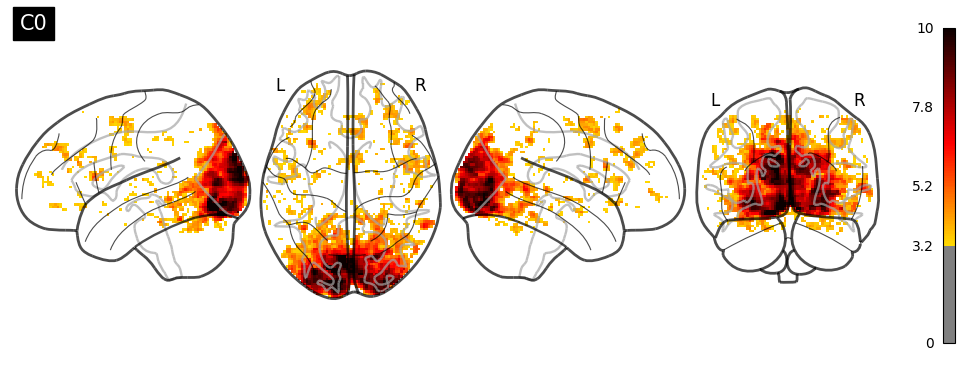

In [6]:
plot_glass_brain(mod.compute_contrast('C0', output_type='z_score'),
                threshold=3.2, colorbar=True,
                display_mode='lzry', 
                title='C0')

#### **Brain activations for simple sentences (S0)**

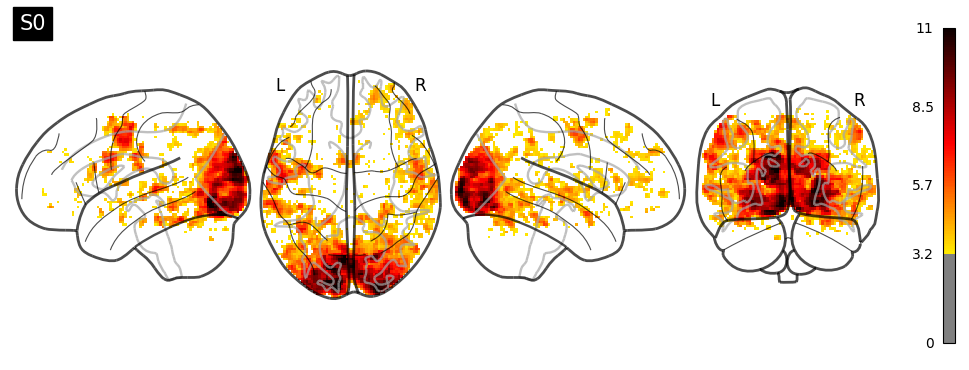

In [7]:
plot_glass_brain(mod.compute_contrast('S0', output_type='z_score'),
                threshold=3.2, colorbar=True,
                display_mode='lzry', 
                title='S0')

#### **Brain activations for complex sentences (S1)**

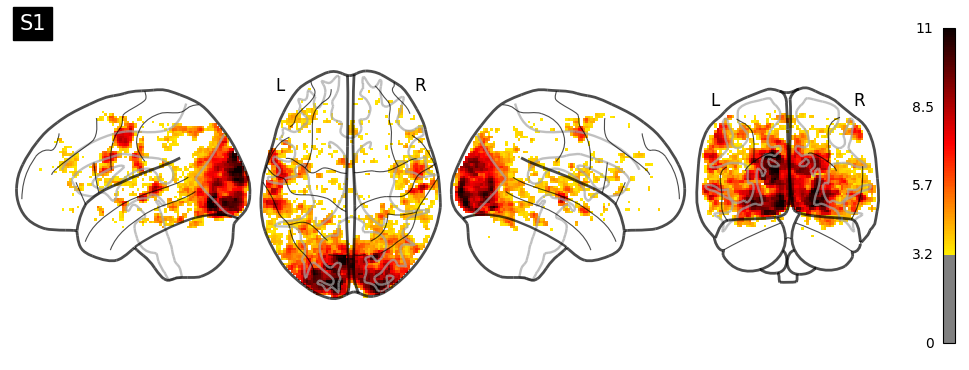

In [8]:
plot_glass_brain(mod.compute_contrast('S1', output_type='z_score'),
                threshold=3.2, colorbar=True,
                display_mode='lzry', 
                title='S1')

#### **Contrast between complex sentences (S1) and control ones (C0)**

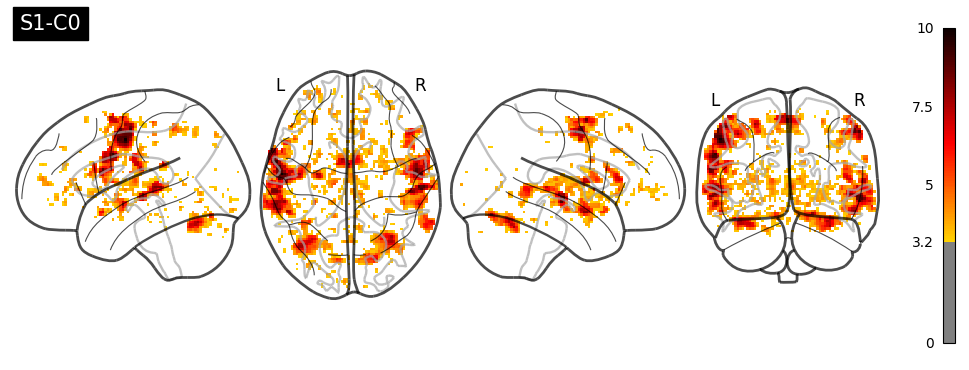

In [9]:
plot_glass_brain(mod.compute_contrast('S1-C0', output_type='z_score'),
                threshold=3.2, colorbar=True,
                display_mode='lzry', 
                title='S1-C0')